In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
RAW_PATH = Path("../data/raw")
PROCESSED_PATH = Path("../data/processed")

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

In [3]:
customers = pd.read_csv(RAW_PATH / "olist_customers_dataset.csv")
geolocation = pd.read_csv(RAW_PATH / "olist_geolocation_dataset.csv")
order_items = pd.read_csv(RAW_PATH / "olist_order_items_dataset.csv")
payments = pd.read_csv(RAW_PATH / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(RAW_PATH / "olist_order_reviews_dataset.csv")
orders = pd.read_csv(RAW_PATH / "olist_orders_dataset.csv")
products = pd.read_csv(RAW_PATH / "olist_products_dataset.csv")
sellers = pd.read_csv(RAW_PATH / "olist_sellers_dataset.csv")
translation = pd.read_csv(
    RAW_PATH / "product_category_name_translation.csv"
)

In [5]:
tables = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "translation": translation
}

In [6]:
for name, df in tables.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
geolocation: (1000163, 5)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
orders: (99441, 8)
products: (32951, 9)
sellers: (3095, 4)
translation: (71, 2)


In [9]:
for name, df in tables.items():
    print(f"\n{name.upper()}")
    print(df.head(2))


CUSTOMERS
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  

GEOLOCATION
   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.639292   
1                         1046       -23.546081       -46.644820   

  geolocation_city geolocation_state  
0        sao paulo                SP  
1        sao paulo                SP  

ORDER_ITEMS
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   

                         product_id                   

In [10]:
for name, df in tables.items():
    print(f"\n{name.upper()}")
    print(df.dtypes)


CUSTOMERS
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

GEOLOCATION
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str
dtype: object

ORDER_ITEMS
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

PAYMENTS
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

REVIEWS
review_id                    str
order_id                     str
review_score               int64
review_comment_title         str
review_comment

In [11]:
# Define the order date columns that need to be converted to datetime
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

In [12]:
# Convert all selected order date columns from text to datetime
for col in date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

In [13]:
# Find orders where the customer delivery date is earlier than the purchase date
invalid_delivery = orders[
    orders["order_delivered_customer_date"]
    < orders["order_purchase_timestamp"]
]

print("Invalid delivery records:", len(invalid_delivery))

Invalid delivery records: 0


In [14]:
# Find orders where the estimated delivery date is earlier than the purchase date
invalid_estimated = orders[
    orders["order_estimated_delivery_date"]
    < orders["order_purchase_timestamp"]
]

print("Invalid estimated-delivery records:", len(invalid_estimated))

Invalid estimated-delivery records: 0


In [15]:
# Check whether any order_id appears more than once in the orders table
orders["order_id"].duplicated().sum()

np.int64(0)

In [16]:
# Check whether product_id and seller_id contain duplicate records
print("Duplicate products:", products["product_id"].duplicated().sum())
print("Duplicate sellers:", sellers["seller_id"].duplicated().sum())

Duplicate products: 0
Duplicate sellers: 0


In [17]:
# Check for duplicate order-item combinations
print(
    "Duplicate order items:",
    order_items.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum()
)

Duplicate order items: 0


In [18]:
# Check for duplicate payment transaction combinations
print(
    "Duplicate payments:",
    payments.duplicated(
        subset=["order_id", "payment_sequential"]
    ).sum()
)

Duplicate payments: 0


In [19]:
# Check for completely identical rows in the main transactional tables
print("Duplicate order_items rows:", order_items.duplicated().sum())
print("Duplicate payment rows:", payments.duplicated().sum())
print("Duplicate review rows:", reviews.duplicated().sum())

Duplicate order_items rows: 0
Duplicate payment rows: 0
Duplicate review rows: 0


In [20]:
# Create a month field for monthly sales and order trend analysis
orders["order_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [21]:
# Calculate the number of days between purchase and actual customer delivery
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

In [22]:
# Round delivery duration to two decimal places for easier analysis
orders["delivery_days"] = orders["delivery_days"].round(2)

In [23]:
# Calculate how many days early or late the order was delivered compared with the estimate
orders["estimated_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

orders["estimated_delay_days"] = orders["estimated_delay_days"].round(2)

In [24]:
# Display the newly created fields for a quick verification
orders[
    [
        "order_id",
        "order_month",
        "delivery_days",
        "estimated_delay_days"
    ]
].head(10)

,order_id,order_month,delivery_days,estimated_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10,8.44,-7.11
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07,13.78,-5.36
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08,9.39,-17.25
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11,13.21,-12.98
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02,2.87,-9.24
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07,16.54,-5.54
6,136cce7faa42fdb2cefd53fdc79a6098,2017-04,NaN,NaN
7,6514b8ad8028c9f2cc2374ded245783f,2017-05,9.99,-11.46
8,76c6e866289321a7c93b82b54852dc33,2017-01,9.82,-31.41
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07,18.22,-6.28


In [25]:
# Verify the data types of the newly created fields
orders[
    [
        "order_month",
        "delivery_days",
        "estimated_delay_days"
    ]
].dtypes

order_month                 str
delivery_days           float64
estimated_delay_days    float64
dtype: object

In [26]:
# Get basic statistics for delivery and delay calculations
orders[
    [
        "delivery_days",
        "estimated_delay_days"
    ]
].describe()

,delivery_days,estimated_delay_days
count,96476.000000,96476.000000
mean,12.558687,-11.179116
std,9.546528,10.186115
min,0.530000,-146.020000
25%,6.770000,-16.240000
50%,10.220000,-11.950000
75%,15.720000,-6.390000
max,209.630000,188.980000


In [28]:
# Calculate the value of each order item including its freight cost
order_items["item_value"] = (
    order_items["price"]
    + order_items["freight_value"]
)

In [29]:
# Verify that the new item_value column was created correctly
order_items[["price", "freight_value", "item_value"]].head()

,price,freight_value,item_value
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


In [30]:
# Calculate product value, freight value, and total order value for each order
order_value = (
    order_items
    .groupby("order_id", as_index=False)
    .agg(
        product_value=("price", "sum"),
        freight_value=("freight_value", "sum"),
        order_value=("item_value", "sum")
    )
)

In [31]:
# Preview the calculated order-level values
order_value.head(10)

,order_id,product_value,freight_value,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04
5,00048cc3ae777c65dbb7d2a0634bc1ea,21.90,12.69,34.59
6,00054e8431b9d7675808bcb819fb4a32,19.90,11.85,31.75
7,000576fe39319847cbb9d288c5617fa6,810.00,70.75,880.75
8,0005a1a1728c9d785b8e2b08b904576c,145.95,11.65,157.60
9,0005f50442cb953dcd1d21e1fb923495,53.99,11.40,65.39


In [32]:
# Review basic statistics of the calculated order values
order_value[
    ["product_value", "freight_value", "order_value"]
].describe()

,product_value,freight_value,order_value
count,98666.000000,98666.000000,98666.000000
mean,137.754076,22.823562,160.577638
std,210.645145,21.650909,220.466087
min,0.850000,0.000000,9.590000
25%,45.900000,13.850000,61.980000
50%,86.900000,17.170000,105.290000
75%,149.900000,24.040000,176.870000
max,13440.000000,1794.960000,13664.080000


In [33]:
# Check for missing values in the calculated order-value table
print(order_value[["product_value", "freight_value", "order_value"]].isna().sum())

product_value    0
freight_value    0
order_value      0
dtype: int64


In [34]:
# Compare the number of unique orders in the item table with the calculated order-value table
print("Orders in order_items:", order_items["order_id"].nunique())
print("Orders in order_value:", order_value["order_id"].nunique())

Orders in order_items: 98666
Orders in order_value: 98666


In [35]:
# Add order-level product, freight, and total value information to the orders table
orders_clean = orders.merge(
    order_value,
    on="order_id",
    how="left"
)

In [36]:
# Check that the merge did not accidentally create extra order rows
print("Rows before merge:", len(orders))
print("Rows after merge:", len(orders_clean))

Rows before merge: 99441
Rows after merge: 99441


In [37]:
# Verify that the order-value columns were added correctly
orders_clean[
    [
        "order_id",
        "order_month",
        "product_value",
        "freight_value",
        "order_value"
    ]
].head(10)

,order_id,order_month,product_value,freight_value,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02,19.90,8.72,28.62
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07,147.90,27.36,175.26
6,136cce7faa42fdb2cefd53fdc79a6098,2017-04,49.90,16.05,65.95
7,6514b8ad8028c9f2cc2374ded245783f,2017-05,59.99,15.17,75.16
8,76c6e866289321a7c93b82b54852dc33,2017-01,19.90,16.05,35.95
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07,149.99,19.77,169.76


In [38]:
# Select the customer fields needed for customer and geographic analysis
customer_info = customers[
    [
        "customer_id",
        "customer_unique_id",
        "customer_city",
        "customer_state"
    ]
]

In [39]:
# Add customer identity and location information to the orders table
orders_clean = orders_clean.merge(
    customer_info,
    on="customer_id",
    how="left"
)

In [40]:
# Verify that adding customer information did not multiply order rows
print("Rows after customer merge:", len(orders_clean))

Rows after customer merge: 99441


In [41]:
# Preview orders with the newly added customer information
orders_clean[
    [
        "order_id",
        "customer_id",
        "customer_unique_id",
        "customer_city",
        "customer_state"
    ]
].head(10)

,order_id,customer_id,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,36edbb3fb164b1f16485364b6fb04c73,santa rosa,RS
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,39382392765b6dc74812866ee5ee92a7,faxinalzinho,RS
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,299905e3934e9e181bfb2e164dd4b4f8,sorocaba,SP


In [42]:
# Calculate one average review score for each order
review_summary = (
    reviews
    .groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean")
    )
)

In [43]:
# Preview the order-level review summary
review_summary.head(10)

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0
5,00048cc3ae777c65dbb7d2a0634bc1ea,4.0
6,00054e8431b9d7675808bcb819fb4a32,4.0
7,000576fe39319847cbb9d288c5617fa6,5.0
8,0005a1a1728c9d785b8e2b08b904576c,1.0
9,0005f50442cb953dcd1d21e1fb923495,4.0


In [44]:
# Add the aggregated review score to the analysis-ready orders table
orders_clean = orders_clean.merge(
    review_summary,
    on="order_id",
    how="left"
)

In [45]:
# Verify that the review merge did not multiply order rows
print("Rows after review merge:", len(orders_clean))

Rows after review merge: 99441


In [46]:
# Calculate total payment value and number of payment transactions for each order
payment_summary = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_count=("payment_sequential", "count")
    )
)

In [47]:
# Preview the order-level payment summary
payment_summary.head(10)

,order_id,payment_value,payment_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,1
2,000229ec398224ef6ca0657da4fc703e,216.87,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1
5,00048cc3ae777c65dbb7d2a0634bc1ea,34.59,1
6,00054e8431b9d7675808bcb819fb4a32,31.75,1
7,000576fe39319847cbb9d288c5617fa6,880.75,1
8,0005a1a1728c9d785b8e2b08b904576c,157.60,1
9,0005f50442cb953dcd1d21e1fb923495,65.39,1


In [48]:
# Add the aggregated payment information to the analysis-ready orders table
orders_clean = orders_clean.merge(
    payment_summary,
    on="order_id",
    how="left"
)

In [49]:
# Verify that the payment merge did not multiply order rows
print("Rows after payment merge:", len(orders_clean))
print("Original order rows:", len(orders))

Rows after payment merge: 99441
Original order rows: 99441


In [50]:
# Check the final number of rows and columns in the analysis-ready orders table
print("Shape of orders_clean:", orders_clean.shape)

Shape of orders_clean: (99441, 20)


In [51]:
# Display all columns currently available in the analysis-ready orders table
print(orders_clean.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_month', 'delivery_days', 'estimated_delay_days', 'product_value', 'freight_value', 'order_value', 'customer_unique_id', 'customer_city', 'customer_state', 'review_score', 'payment_value', 'payment_count']


In [52]:
# Check missing values in every column of the analysis-ready orders table
orders_clean.isna().sum().sort_values(ascending=False)

delivery_days                    2965
estimated_delay_days             2965
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
product_value                     775
freight_value                     775
order_value                       775
review_score                      768
order_approved_at                 160
payment_value                       1
payment_count                       1
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
order_month                         0
customer_unique_id                  0
customer_city                       0
customer_state                      0
dtype: int64

In [53]:
# Preview the first five rows of the analysis-ready orders table
orders_clean.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,delivery_days,estimated_delay_days,product_value,freight_value,order_value,customer_unique_id,customer_city,customer_state,review_score,payment_value,payment_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,8.44,-7.11,29.99,8.72,38.71,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,4.0,38.71,3.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,13.78,-5.36,118.70,22.76,141.46,af07308b275d755c9edb36a90c618231,barreiras,BA,4.0,141.46,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,9.39,-17.25,159.90,19.22,179.12,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,5.0,179.12,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,13.21,-12.98,45.00,27.20,72.20,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,5.0,72.20,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,2.87,-9.24,19.90,8.72,28.62,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,5.0,28.62,1.0


In [54]:
# Count how many unique orders each actual customer has placed
customer_order_count = (
    orders_clean
    .groupby("customer_unique_id")
    .agg(
        order_count=("order_id", "nunique")
    )
    .reset_index()
)

In [55]:
# Preview the number of orders associated with each customer
customer_order_count.head(10)

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
5,0004bd2a26a76fe21f786e4fbd80607f,1
6,00050ab1314c0e55a6ca13cf7181fecf,1
7,00053a61a98854899e70ed204dd4bafe,1
8,0005e1862207bf6ccc02e4228effd9a0,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1


In [56]:
# Check how many customers have each number of orders
customer_order_count["order_count"].value_counts().sort_index()

order_count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [57]:
# Classify customers based on whether they placed one order or multiple orders
customer_order_count["customer_type"] = np.where(
    customer_order_count["order_count"] == 1,
    "One-time",
    "Repeat"
)

In [58]:
# Count how many customers belong to each customer type
customer_order_count["customer_type"].value_counts()

customer_type
One-time    93099
Repeat       2997
Name: count, dtype: int64

In [59]:
# Calculate the percentage of customers in each customer type
customer_order_count["customer_type"].value_counts(normalize=True).mul(100).round(2)

customer_type
One-time    96.88
Repeat       3.12
Name: proportion, dtype: float64

In [60]:
# Create one analytical row for each actual customer
customer_analysis = (
    orders_clean
    .groupby("customer_unique_id", as_index=False)
    .agg(
        order_count=("order_id", "nunique"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean"),
        average_review_score=("review_score", "mean"),
        customer_city=("customer_city", "first"),
        customer_state=("customer_state", "first")
    )
)

In [61]:
# Add the one-time or repeat classification to the customer analysis table
customer_analysis["customer_type"] = np.where(
    customer_analysis["order_count"] == 1,
    "One-time",
    "Repeat"
)

In [62]:
# Preview the first ten customer analysis records
customer_analysis.head(10)

,customer_unique_id,order_count,total_order_value,average_order_value,average_review_score,customer_city,customer_state,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,cajamar,SP,One-time
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,osasco,SP,One-time
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,sao jose,SC,One-time
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,belem,PA,One-time
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,sorocaba,SP,One-time
5,0004bd2a26a76fe21f786e4fbd80607f,1,166.98,166.98,4.0,sao paulo,SP,One-time
6,00050ab1314c0e55a6ca13cf7181fecf,1,35.38,35.38,4.0,campinas,SP,One-time
7,00053a61a98854899e70ed204dd4bafe,1,419.18,419.18,1.0,curitiba,PR,One-time
8,0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12,4.0,teresopolis,RJ,One-time
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1,129.76,129.76,1.0,sao luis,MA,One-time


In [63]:
# Check the number of customers and analytical columns
print("Customer analysis shape:", customer_analysis.shape)
print("Unique customers:", customer_analysis["customer_unique_id"].nunique())

Customer analysis shape: (96096, 8)
Unique customers: 96096


In [64]:
# Add English product category names using the translation table
products_with_category = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

In [65]:
# Preview product categories with their English translations
products_with_category[
    [
        "product_id",
        "product_category_name",
        "product_category_name_english"
    ]
].head(10)

,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,musical_instruments
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,cool_stuff
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,furniture_decor
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,home_appliances
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,toys


In [66]:
# Add the English product category to each ordered item
items_category = order_items.merge(
    products_with_category[
        [
            "product_id",
            "product_category_name_english"
        ]
    ],
    on="product_id",
    how="left"
)

In [67]:
# Preview order items with their translated product categories
items_category[
    [
        "order_id",
        "product_id",
        "price",
        "product_category_name_english"
    ]
].head(10)

,order_id,product_id,price,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,garden_tools
5,00048cc3ae777c65dbb7d2a0634bc1ea,ef92defde845ab8450f9d70c526ef70f,21.90,housewares
6,00054e8431b9d7675808bcb819fb4a32,8d4f2bb7e93e6710a28f34fa83ee7d28,19.90,telephony
7,000576fe39319847cbb9d288c5617fa6,557d850972a7d6f792fd18ae1400d9b6,810.00,garden_tools
8,0005a1a1728c9d785b8e2b08b904576c,310ae3c140ff94b03219ad0adc3c778f,145.95,health_beauty
9,0005f50442cb953dcd1d21e1fb923495,4535b0e1091c278dfd193e5a1d63b39f,53.99,books_technical


In [68]:
# Calculate orders, units sold, and revenue for each product category
category_analysis = (
    items_category
    .groupby(
        "product_category_name_english",
        dropna=False
    )
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("order_item_id", "count"),
        revenue=("price", "sum")
    )
    .reset_index()
)

In [69]:
# Sort product categories from highest to lowest revenue
category_analysis = category_analysis.sort_values(
    "revenue",
    ascending=False
)

In [70]:
# Display the top ten product categories by revenue
category_analysis.head(10)

,product_category_name_english,orders,units_sold,revenue
43,health_beauty,8836,9670,1258681.34
70,watches_gifts,5624,5991,1205005.68
7,bed_bath_table,9417,11115,1036988.68
65,sports_leisure,7720,8641,988048.97
15,computers_accessories,6689,7827,911954.32
39,furniture_decor,6449,8334,729762.49
20,cool_stuff,3632,3796,635290.85
49,housewares,5884,6964,632248.66
5,auto,3897,4235,592720.11
42,garden_tools,3518,4347,485256.46


In [71]:
# Check whether any ordered products have no translated category
print(
    "Missing category names:",
    category_analysis["product_category_name_english"].isna().sum()
)

Missing category names: 1


### Geographic analysis


In [72]:
# Calculate order count and revenue for each customer state
state_analysis = (
    orders_clean
    .groupby("customer_state", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("order_value", "sum")
    )
)

In [73]:
# Sort states from highest to lowest number of orders
state_analysis = state_analysis.sort_values(
    "orders",
    ascending=False
)

In [74]:
# Display the top ten states by order volume
state_analysis.head(10)

,customer_state,orders,revenue
25,SP,41746,5921678.12
18,RJ,12852,2129681.98
10,MG,11635,1856161.49
22,RS,5466,885826.76
17,PR,5045,800935.44
23,SC,3637,610213.60
4,BA,3380,611506.67
6,DF,2140,353229.44
7,ES,2033,324801.91
8,GO,2020,347706.93


In [75]:
# Check the number of unique customer states in the analysis
print("Unique states:", state_analysis["customer_state"].nunique())
print("Missing states:", state_analysis["customer_state"].isna().sum())


Unique states: 27
Missing states: 0


### Monthly analysis

In [76]:
# Calculate total orders and revenue for each purchase month
monthly_orders = (
    orders_clean
    .groupby("order_month")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("order_value", "sum")
    )
    .reset_index()
)

In [77]:
# Sort the monthly analysis from earliest to latest month
monthly_orders = monthly_orders.sort_values("order_month")

In [78]:
# Preview the monthly order and revenue analysis
monthly_orders.head(10)

,order_month,orders,revenue
0,2016-09,4,354.75
1,2016-10,324,56808.84
2,2016-12,1,19.62
3,2017-01,800,137188.49
4,2017-02,1780,286280.62
5,2017-03,2682,432048.59
6,2017-04,2404,412422.24
7,2017-05,3700,586190.95
8,2017-06,3245,502963.04
9,2017-07,4026,584971.62


In [79]:
# Check the number of months and the overall analysis period
print("Number of months:", len(monthly_orders))
print("First month:", monthly_orders["order_month"].min())
print("Last month:", monthly_orders["order_month"].max())

Number of months: 25
First month: 2016-09
Last month: 2018-10


### Delivery VS Review analysis


In [80]:
# Keep only orders that have both delivery-delay and review-score information
delay_review_data = orders_clean.dropna(
    subset=["estimated_delay_days", "review_score"]
)

In [81]:
# Calculate average delivery delay and order count for each review score
delay_review = (
    delay_review_data
    .groupby("review_score", as_index=False)
    .agg(
        average_delay_days=("estimated_delay_days", "mean"),
        orders=("order_id", "nunique")
    )
)

In [82]:
# Round average delivery delay values to two decimal places
delay_review["average_delay_days"] = (
    delay_review["average_delay_days"].round(2)
)

In [83]:
# Display the delivery-delay and review-score relationship
delay_review

,review_score,average_delay_days,orders
0,1.000000,-3.34,9316
1,1.500000,-5.34,8
2,2.000000,-7.94,2916
3,2.500000,-6.82,30
4,3.000000,-10.08,7916
5,3.333333,-13.09,1
6,3.500000,-13.22,23
7,4.000000,-11.68,18868
8,4.333333,-10.29,1
9,4.500000,-12.36,53


### EDA: Monthly Orders & Revenue

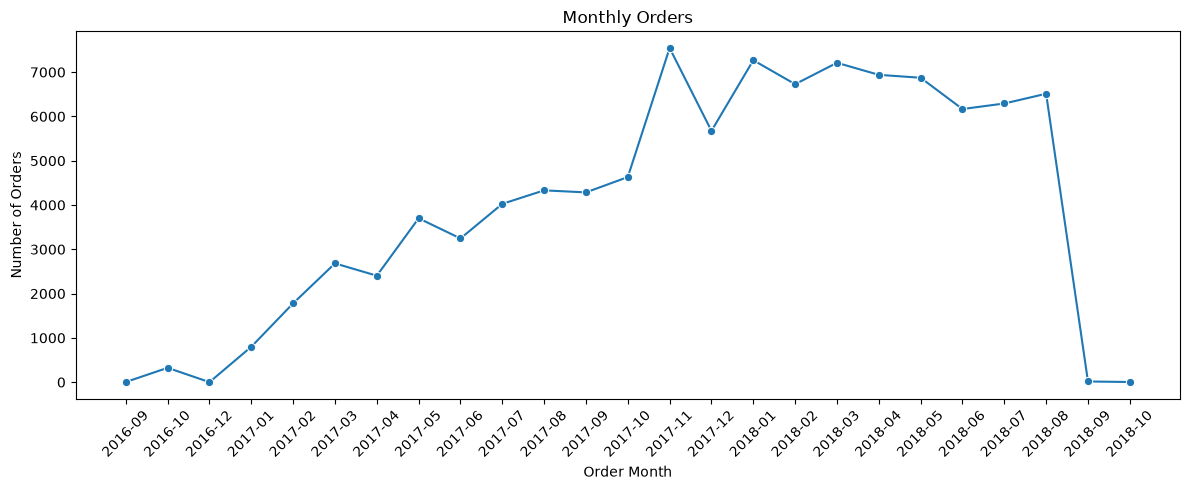

In [84]:
# Plot the number of orders received each month
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_orders,
    x="order_month",
    y="orders",
    marker="o"
)

plt.title("Monthly Orders")
plt.xlabel("Order Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

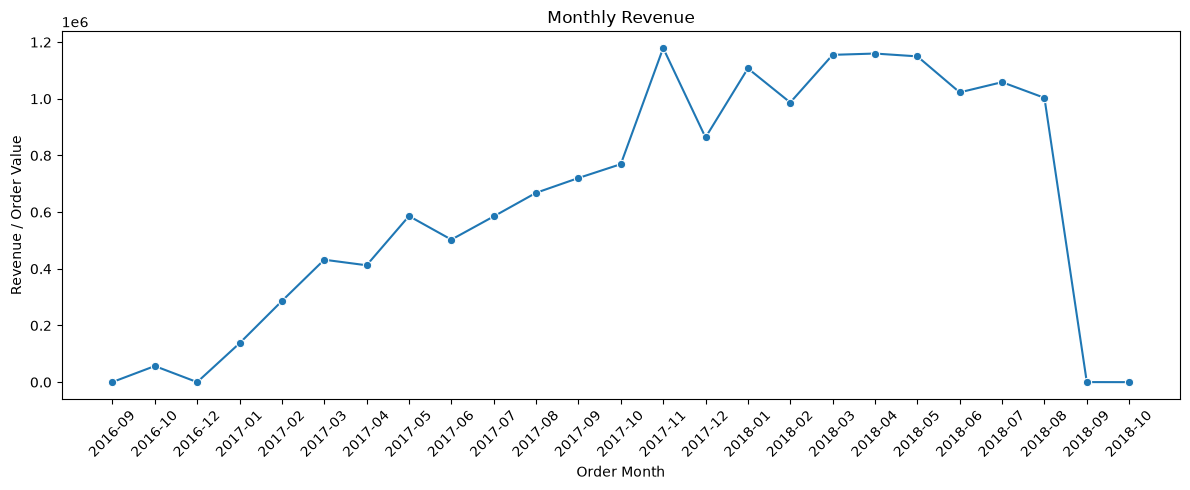

In [85]:
# Plot total order value generated each month
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_orders,
    x="order_month",
    y="revenue",
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Order Month")
plt.ylabel("Revenue / Order Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

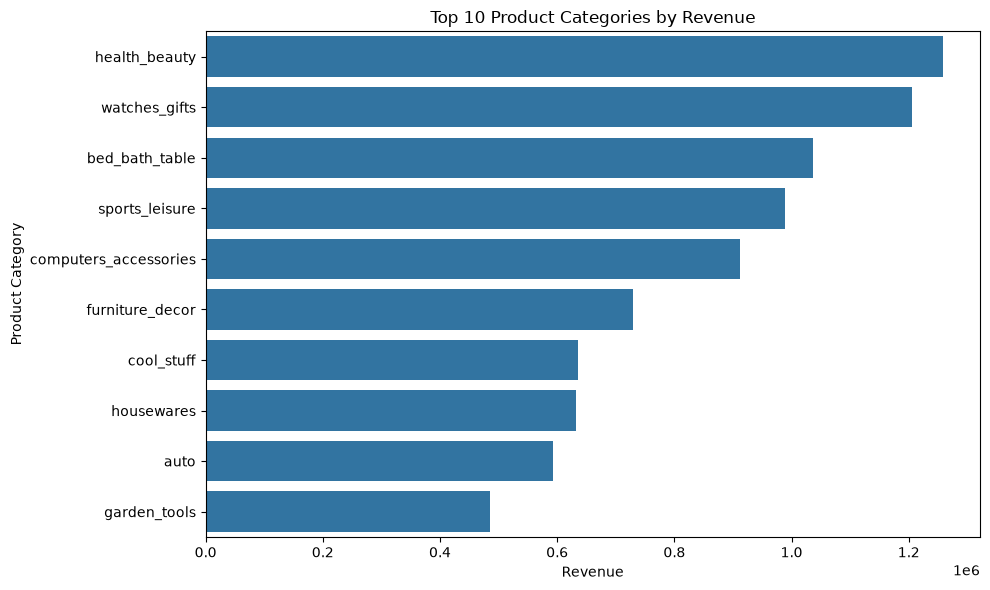

In [86]:
# Plot the top 10 product categories by revenue
top_categories = category_analysis.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_categories,
    x="revenue",
    y="product_category_name_english"
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

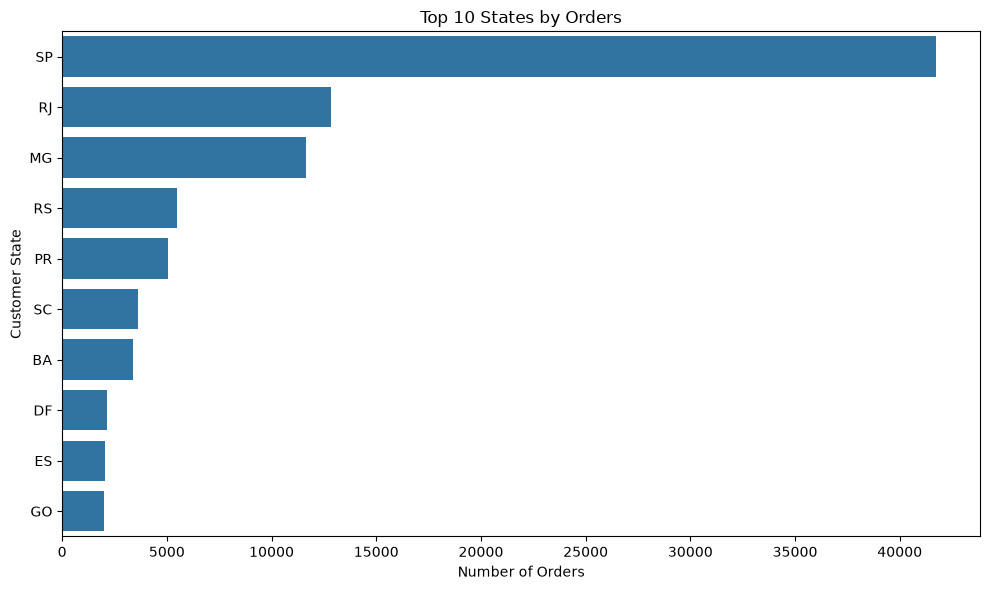

In [87]:
# Plot the top 10 customer states by order volume
top_states = state_analysis.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_states,
    x="orders",
    y="customer_state"
)

plt.title("Top 10 States by Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()

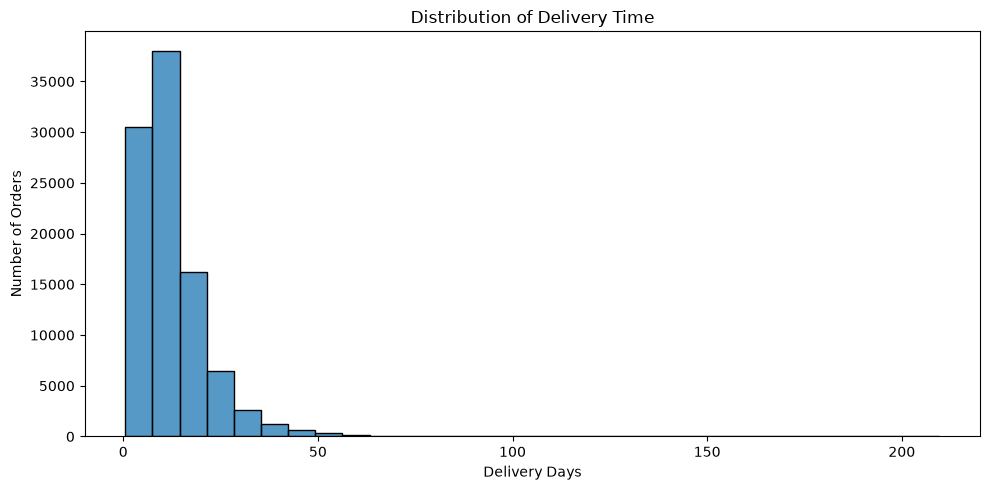

In [88]:
# Plot the distribution of actual delivery times in days
plt.figure(figsize=(10, 5))

sns.histplot(
    data=orders_clean.dropna(subset=["delivery_days"]),
    x="delivery_days",
    bins=30
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

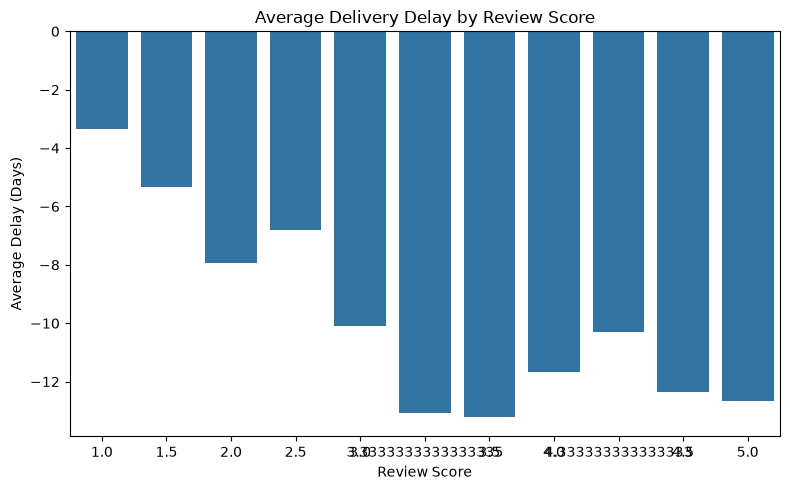

In [89]:
# Compare average delivery delay across different review scores
plt.figure(figsize=(8, 5))

sns.barplot(
    data=delay_review,
    x="review_score",
    y="average_delay_days"
)

plt.title("Average Delivery Delay by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delay (Days)")
plt.tight_layout()
plt.show()

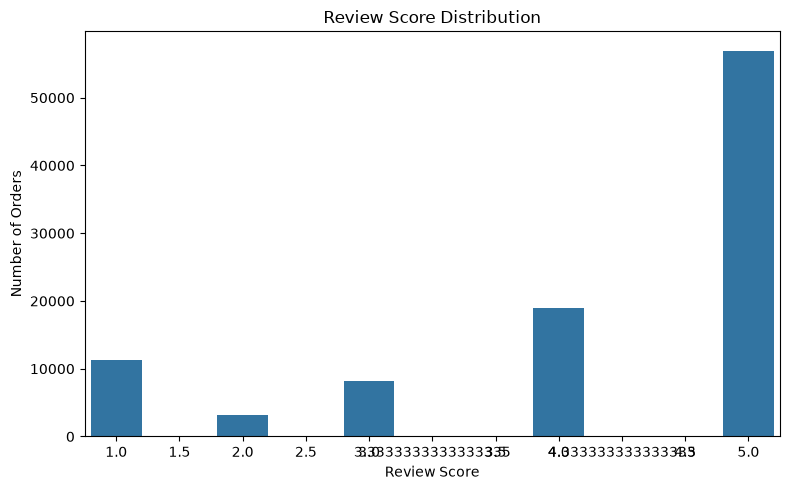

In [90]:
# Plot how frequently each review score occurs
plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders_clean,
    x="review_score"
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [91]:
# Confirm the main analytical tables created during Phase 3
print("orders_clean:", orders_clean.shape)
print("customer_analysis:", customer_analysis.shape)
print("category_analysis:", category_analysis.shape)
print("state_analysis:", state_analysis.shape)
print("monthly_orders:", monthly_orders.shape)
print("delay_review:", delay_review.shape)

orders_clean: (99441, 20)
customer_analysis: (96096, 8)
category_analysis: (72, 4)
state_analysis: (27, 3)
monthly_orders: (25, 3)
delay_review: (11, 3)


In [92]:
# Create integer review-score categories only for visualization
orders_clean["review_score_chart"] = (
    orders_clean["review_score"]
    .round()
    .astype("Int64")
)

In [93]:
# Calculate average delivery delay for each rounded review-score category
delay_review_chart = (
    orders_clean
    .dropna(subset=["estimated_delay_days", "review_score_chart"])
    .groupby("review_score_chart", as_index=False)
    .agg(
        average_delay_days=("estimated_delay_days", "mean"),
        orders=("order_id", "nunique")
    )
)

delay_review_chart["average_delay_days"] = (
    delay_review_chart["average_delay_days"].round(2)
)

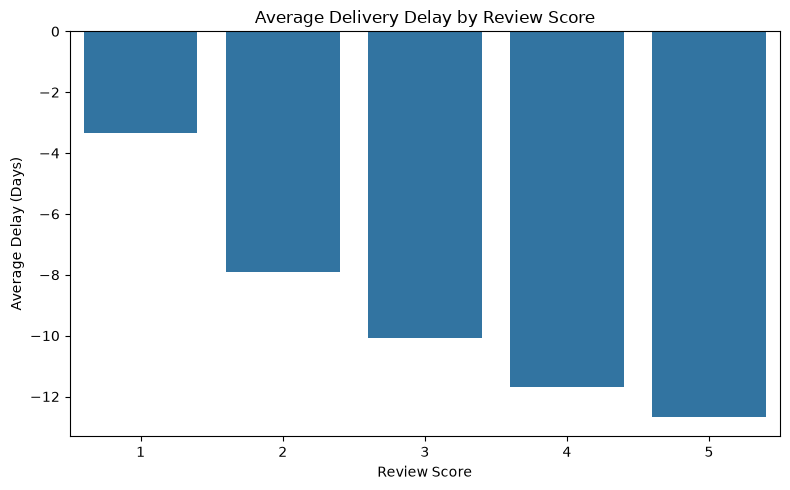

In [94]:
# Plot average delivery delay using clean 1–5 review-score categories
plt.figure(figsize=(8, 5))

sns.barplot(
    data=delay_review_chart,
    x="review_score_chart",
    y="average_delay_days"
)

plt.title("Average Delivery Delay by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delay (Days)")
plt.xticks([0, 1, 2, 3, 4], ["1", "2", "3", "4", "5"])
plt.tight_layout()
plt.show()

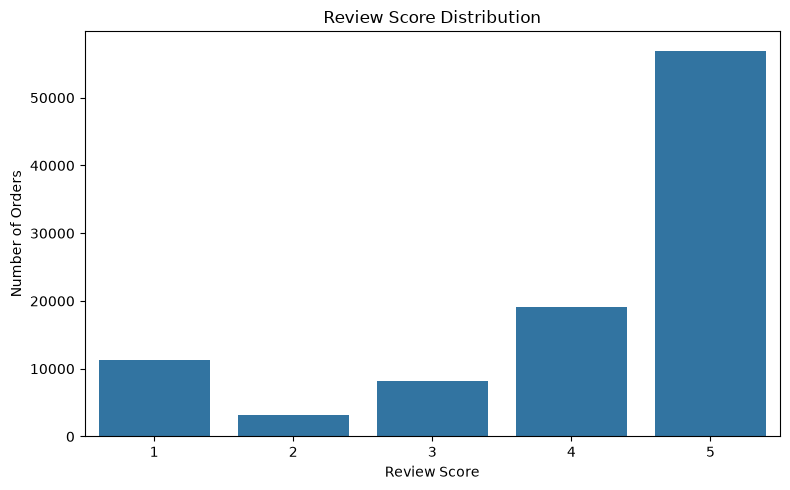

In [95]:
# Plot the number of orders for each clean review-score category
plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders_clean,
    x="review_score_chart"
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.xticks([0, 1, 2, 3, 4], ["1", "2", "3", "4", "5"])
plt.tight_layout()
plt.show()

In [96]:
# Save the analysis-ready order-level table for later analysis
orders_clean.to_csv(
    PROCESSED_PATH / "orders_clean.csv",
    index=False
)

In [97]:
# Save cleaned order-item and customer-level analytical tables
order_items.to_csv(
    PROCESSED_PATH / "order_items_clean.csv",
    index=False
)

customer_analysis.to_csv(
    PROCESSED_PATH / "customer_analysis.csv",
    index=False
)

In [98]:
# Save category and state-level analytical tables
category_analysis.to_csv(
    PROCESSED_PATH / "category_analysis.csv",
    index=False
)

state_analysis.to_csv(
    PROCESSED_PATH / "state_analysis.csv",
    index=False
)

In [99]:
# Save monthly performance and delivery-review analytical tables
monthly_orders.to_csv(
    PROCESSED_PATH / "monthly_orders.csv",
    index=False
)

delay_review.to_csv(
    PROCESSED_PATH / "delay_review.csv",
    index=False
)

In [100]:
# List all files currently saved in the processed-data folder
for file in PROCESSED_PATH.iterdir():
    print(file.name)

category_analysis.csv
customer_analysis.csv
data_dictionary.csv
delay_review.csv
monthly_orders.csv
orders_clean.csv
order_items_clean.csv
state_analysis.csv


In [101]:
# Check that all required Phase 3 output files were created
expected_files = [
    "orders_clean.csv",
    "order_items_clean.csv",
    "customer_analysis.csv",
    "category_analysis.csv",
    "state_analysis.csv",
    "monthly_orders.csv",
    "delay_review.csv"
]

for file_name in expected_files:
    file_path = PROCESSED_PATH / file_name
    print(file_name, "->", "FOUND" if file_path.exists() else "MISSING")

orders_clean.csv -> FOUND
order_items_clean.csv -> FOUND
customer_analysis.csv -> FOUND
category_analysis.csv -> FOUND
state_analysis.csv -> FOUND
monthly_orders.csv -> FOUND
delay_review.csv -> FOUND


In [102]:
# Display the size of each exported CSV file in megabytes
for file_name in expected_files:
    file_path = PROCESSED_PATH / file_name
    if file_path.exists():
        size_mb = file_path.stat().st_size / (1024 * 1024)
        print(f"{file_name}: {size_mb:.2f} MB")

orders_clean.csv: 25.67 MB
order_items_clean.csv: 15.26 MB
customer_analysis.csv: 7.41 MB
category_analysis.csv: 0.00 MB
state_analysis.csv: 0.00 MB
monthly_orders.csv: 0.00 MB
delay_review.csv: 0.00 MB


In [103]:
# Confirm that orders_clean still contains one row per order
print("Total rows:", len(orders_clean))
print("Unique orders:", orders_clean["order_id"].nunique())
print("Duplicate order IDs:", orders_clean["order_id"].duplicated().sum())

Total rows: 99441
Unique orders: 99441
Duplicate order IDs: 0


In [104]:
# Confirm that customer_analysis contains one row per actual customer
print("Customer rows:", len(customer_analysis))
print("Unique customers:", customer_analysis["customer_unique_id"].nunique())
print(
    "Duplicate customer IDs:",
    customer_analysis["customer_unique_id"].duplicated().sum()
)

Customer rows: 96096
Unique customers: 96096
Duplicate customer IDs: 0


In [105]:
# Verify that the main analytical tables contain data
print("Category rows:", len(category_analysis))
print("State rows:", len(state_analysis))
print("Monthly rows:", len(monthly_orders))
print("Delay-review rows:", len(delay_review))


Category rows: 72
State rows: 27
Monthly rows: 25
Delay-review rows: 11


In [106]:
# Display the final Phase 3 output files
print("Processed files:")

for file_name in expected_files:
    print("✓", file_name)

Processed files:
✓ orders_clean.csv
✓ order_items_clean.csv
✓ customer_analysis.csv
✓ category_analysis.csv
✓ state_analysis.csv
✓ monthly_orders.csv
✓ delay_review.csv
